In [2]:
# Import libraries
import pandas as pd  
import numpy as np   
import matplotlib.pyplot as plt  
import seaborn as sns  

# Set plot style
plt.rcParams['axes.unicode_minus'] = False

# Load data
df = pd.read_csv("Crime Economics - data.csv")
print("Original shape:", df.shape)

# Basic info
print("\nFirst 5 rows:")
print(df.head())
print("\nData info:")
print(df.info())

Original shape: (114, 10)

First 5 rows:
       Country  Crime Rate  Unemployment (%)   HDI  \
0  Afghanistan       76.31              11.2  0.51   
1      Albania       42.53              11.3  0.80   
2      Algeria       52.03              11.5  0.75   
3    Argentina       63.82               7.0  0.85   
4      Armenia       22.79               7.7  0.78   

  Population Density (per sq. km)  Weapons per 100 persons Per Capita Income  \
0                           57.00                     12.5            508.00   
1                          100.00                     12.0          5,181.00   
2                           18.00                      2.1          3,368.00   
3                           16.00                      7.4          8,476.00   
4                           99.00                      6.1          4,266.00   

   Gini Coefficient  Literacy Rate  Happiness Index  
0              27.8           0.38             2.52  
1              33.2           0.98           

In [3]:
# Remove duplicate rows
df = df.drop_duplicates()
print("\nShape after removing duplicates:", df.shape)


Shape after removing duplicates: (114, 10)


In [5]:
# Remove missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())
df = df.dropna()
print("Shape after removing missing values:", df.shape)


Missing values before cleaning:
Country                            0
Crime Rate                         0
Unemployment (%)                   0
HDI                                0
Population Density (per sq. km)    0
Weapons per 100 persons            0
Per Capita Income                  0
Gini Coefficient                   0
Literacy Rate                      0
Happiness Index                    0
dtype: int64
Shape after removing missing values: (114, 10)


In [6]:
# Convert columns to numeric first, then filter
numeric_cols = ['Crime Rate', 'Unemployment (%)', 'HDI', 
                'Population Density (per sq. km)', 'Weapons per 100 persons', 
                'Per Capita Income', 'Gini Coefficient', 'Literacy Rate', 'Happiness Index']

# Convert to numeric, force errors to NaN
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove outliers
df = df[df['Crime Rate'] >= 0]
df = df[df['Unemployment (%)'] >= 0]
df = df[df['Population Density (per sq. km)'] >= 0]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (109, 10)


In [7]:
# Create crime rate indicators (adapted to your dataset)
# Use the existing 'Crime Rate' column directly (already a rate, no need to divide by population)
df['Total_Crime_Rate'] = df['Crime Rate']

# If you want to create relative indicators with available columns
df['Crime_Per_Happiness'] = df['Crime Rate'] / df['Happiness Index']
df['Crime_Per_Literacy'] = df['Crime Rate'] / df['Literacy Rate']

print("New crime-related columns added:")
print(df[['Crime Rate', 'Total_Crime_Rate', 'Crime_Per_Happiness', 'Crime_Per_Literacy']].head())


New crime-related columns added:
   Crime Rate  Total_Crime_Rate  Crime_Per_Happiness  Crime_Per_Literacy
0       76.31             76.31            30.281746          200.815789
1       42.53             42.53             8.306641           43.397959
2       52.03             52.03            10.640082           65.037500
3       63.82             63.82            10.762226           65.122449
4       22.79             22.79             4.316288           22.790000


In [8]:
# Show new indicators
print("\nNew features preview:")
print(df[['Crime Rate', 'Total_Crime_Rate', 'Crime_Per_Happiness', 'Crime_Per_Literacy']].head())


New features preview:
   Crime Rate  Total_Crime_Rate  Crime_Per_Happiness  Crime_Per_Literacy
0       76.31             76.31            30.281746          200.815789
1       42.53             42.53             8.306641           43.397959
2       52.03             52.03            10.640082           65.037500
3       63.82             63.82            10.762226           65.122449
4       22.79             22.79             4.316288           22.790000


In [9]:
# Save cleaned data
df.to_csv("Crime_Economics_Cleaned.csv", index=False)
print("\nData cleaning completed!")
print("Final shape:", df.shape)


Data cleaning completed!
Final shape: (109, 13)


In [10]:
# 查看清洗后数据的基本情况
print("Cleaned data shape:", df.shape)
print("\nColumns available:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())


Cleaned data shape: (109, 13)

Columns available:
['Country', 'Crime Rate', 'Unemployment (%)', 'HDI', 'Population Density (per sq. km)', 'Weapons per 100 persons', 'Per Capita Income', 'Gini Coefficient', 'Literacy Rate', 'Happiness Index', 'Total_Crime_Rate', 'Crime_Per_Happiness', 'Crime_Per_Literacy']

First 5 rows:
       Country  Crime Rate  Unemployment (%)   HDI  \
0  Afghanistan       76.31              11.2  0.51   
1      Albania       42.53              11.3  0.80   
2      Algeria       52.03              11.5  0.75   
3    Argentina       63.82               7.0  0.85   
4      Armenia       22.79               7.7  0.78   

   Population Density (per sq. km)  Weapons per 100 persons  \
0                             57.0                     12.5   
1                            100.0                     12.0   
2                             18.0                      2.1   
3                             16.0                      7.4   
4                             99.0    

In [11]:
# 用现有列创建衍生指标（替代原来的Violent/Property Crime Rate）
df['Crime_Rate_Adj'] = df['Crime Rate']
df['Crime_Density'] = df['Crime Rate'] / df['Population Density (per sq. km)']
df['Crime_vs_Income'] = df['Crime Rate'] / df['Per Capita Income']

print("\nNew analysis indicators created:")
print(df[['Crime Rate', 'Crime_Rate_Adj', 'Crime_Density', 'Crime_vs_Income']].head())


New analysis indicators created:
   Crime Rate  Crime_Rate_Adj  Crime_Density  Crime_vs_Income
0       76.31           76.31       1.338772         0.150217
1       42.53           42.53       0.425300              NaN
2       52.03           52.03       2.890556              NaN
3       63.82           63.82       3.988750              NaN
4       22.79           22.79       0.230202              NaN


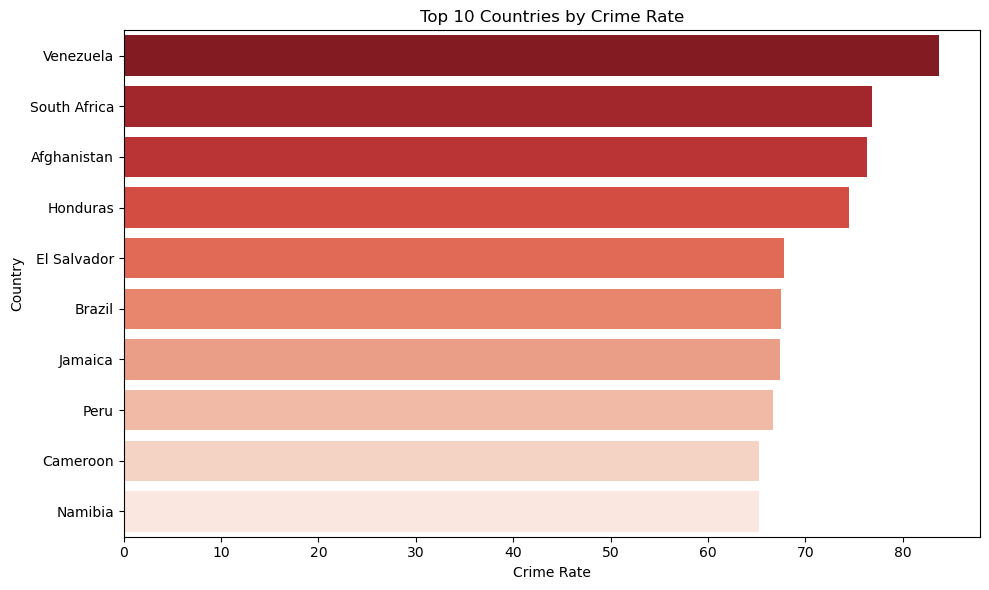

In [12]:
# Top 10 countries by crime rate
top_crime_countries = df.sort_values('Crime Rate', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_crime_countries, x='Crime Rate', y='Country', hue='Country', palette='Reds_r', legend=False)
plt.title("Top 10 Countries by Crime Rate")
plt.xlabel("Crime Rate")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

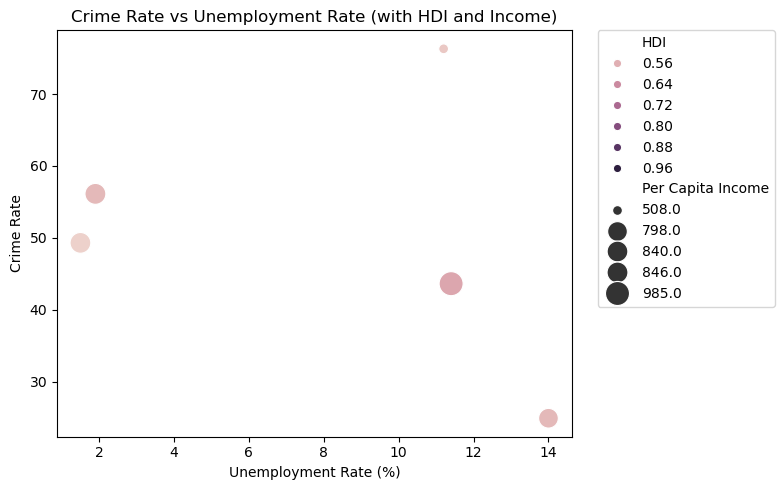

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Unemployment (%)', y='Crime Rate', hue='HDI', size='Per Capita Income', sizes=(50, 300))
plt.title("Crime Rate vs Unemployment Rate (with HDI and Income)")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Crime Rate")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout() 
plt.show()

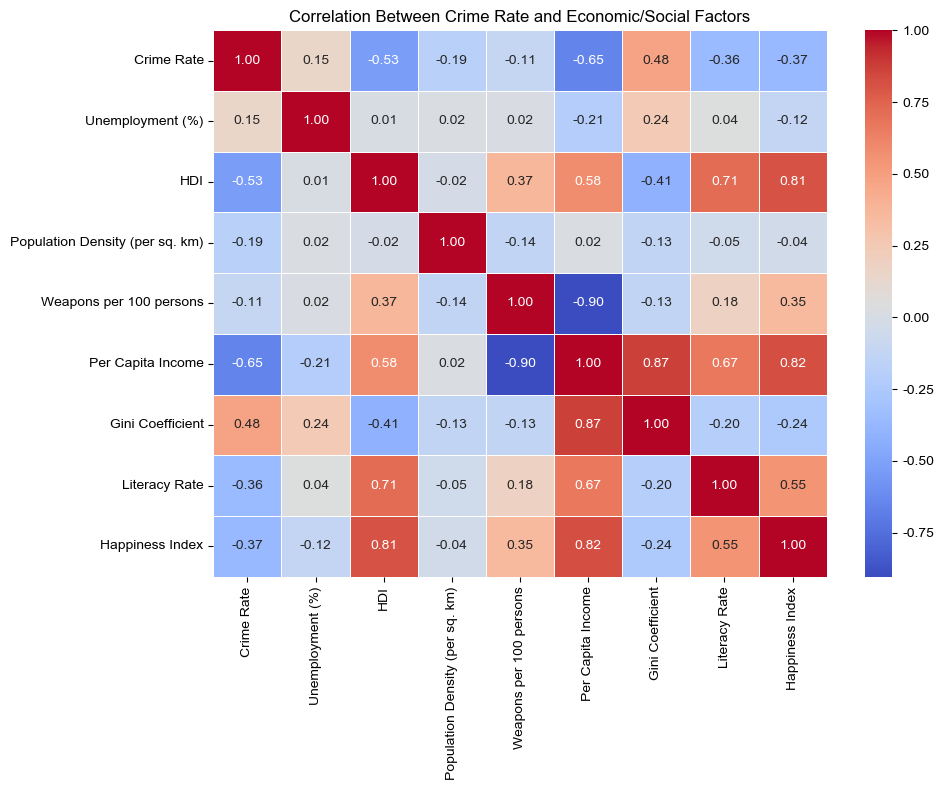

In [46]:
numeric_cols = ['Crime Rate', 'Unemployment (%)', 'HDI', 'Population Density (per sq. km)',
                'Weapons per 100 persons', 'Per Capita Income', 'Gini Coefficient', 'Literacy Rate', 'Happiness Index']
corr_df = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Crime Rate and Economic/Social Factors")
plt.tight_layout()
plt.show()

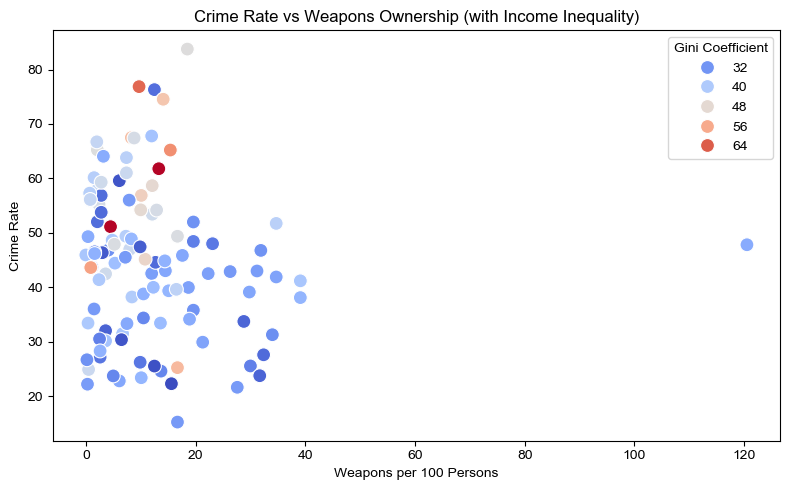

In [47]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Weapons per 100 persons', y='Crime Rate', hue='Gini Coefficient', palette='coolwarm', s=100)
plt.title("Crime Rate vs Weapons Ownership (with Income Inequality)")
plt.xlabel("Weapons per 100 Persons")
plt.ylabel("Crime Rate")
plt.tight_layout()
plt.show()



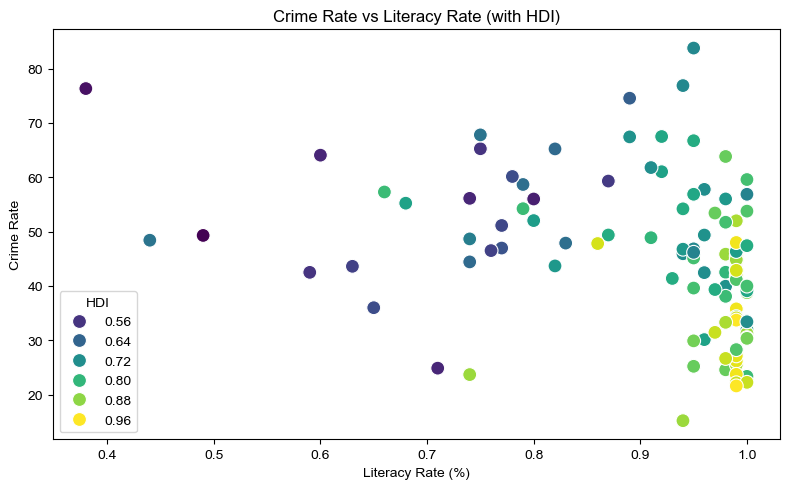

In [48]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Literacy Rate', y='Crime Rate', hue='HDI', palette='viridis', s=100)
plt.title("Crime Rate vs Literacy Rate (with HDI)")
plt.xlabel("Literacy Rate (%)")
plt.ylabel("Crime Rate")
plt.tight_layout()
plt.show()